Clustering asks for structure without target labels. K-means partitions observations into $k$ groups so each point is close to the centroid of its assigned group. The output is useful only when distance in the chosen feature space is meaningful.

## Learning goals

You will implement assignment and centroid updates, track the objective, standardize features, compare several initializations, use an elbow plot carefully, and interpret clusters without pretending they are natural laws.

## The objective

For centroids $\mu_1, \ldots, \mu_k$ and assignment $c_i$, K-means minimizes within-cluster squared distance:

$$
\sum_{i=1}^{n} \lVert x_i - \mu_{c_i} \rVert_2^2.
$$

It alternates two steps:

1. **Assign:** send every point to its nearest centroid.
2. **Update:** replace each centroid with the mean of its assigned points.

Each step cannot increase the objective, but the final answer can depend on the starting centroids.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(21)
centers = np.array([[18, 45], [42, 135], [72, 260]])
parts = [rng.normal(center, [7, 22], size=(90, 2)) for center in centers]
X_raw = np.vstack(parts)
X_raw[:, 0] = np.clip(X_raw[:, 0], 1, None)
X_raw[:, 1] = np.clip(X_raw[:, 1], 5, None)
data = pd.DataFrame(X_raw, columns=["sessions_per_month", "monthly_spend"])
data.describe().round(1)

,sessions_per_month,monthly_spend
count,270.0,270.0
mean,44.1,147.1
std,23.7,91.4
min,3.7,5.0
25%,21.7,63.4
50%,41.3,135.4
75%,68.6,250.9
max,88.2,309.9


## 1. Scale before measuring distance

Monthly spend spans a much larger numeric range than session count. Euclidean distance on raw values would therefore treat a one-unit spending difference exactly like a one-session difference. Standardization gives each feature zero mean and unit standard deviation.

In [2]:
mean = X_raw.mean(axis=0)
scale = X_raw.std(axis=0)
X = (X_raw - mean) / scale

pd.DataFrame(X, columns=data.columns).agg(["mean", "std"]).round(3)

,sessions_per_month,monthly_spend
mean,-0.000,0.000
std,1.002,1.002


## 2. Implement the alternating updates

Broadcasting lets us calculate every point-to-centroid distance in one array. The empty-cluster branch reuses the point with the largest current error.

In [3]:
def kmeans_once(X, k, seed=0, max_iter=100, tolerance=1e-6):
    local_rng = np.random.default_rng(seed)
    centroids = X[local_rng.choice(len(X), size=k, replace=False)].copy()
    inertia_history = []

    for _ in range(max_iter):
        squared_distances = ((X[:, None, :] - centroids[None, :, :]) ** 2).sum(axis=2)
        labels = squared_distances.argmin(axis=1)
        inertia_history.append(squared_distances[np.arange(len(X)), labels].sum())

        new_centroids = []
        for cluster in range(k):
            members = X[labels == cluster]
            if len(members):
                new_centroids.append(members.mean(axis=0))
            else:
                worst_point = squared_distances.min(axis=1).argmax()
                new_centroids.append(X[worst_point])
        new_centroids = np.asarray(new_centroids)

        if np.linalg.norm(new_centroids - centroids) < tolerance:
            centroids = new_centroids
            break
        centroids = new_centroids

    final_distances = ((X[:, None, :] - centroids[None, :, :]) ** 2).sum(axis=2)
    labels = final_distances.argmin(axis=1)
    inertia = final_distances[np.arange(len(X)), labels].sum()
    return labels, centroids, inertia, inertia_history

labels, centroids, inertia, history = kmeans_once(X, k=3, seed=4)
print(f"converged in {len(history)} updates; inertia={inertia:.2f}")

converged in 5 updates; inertia=34.64


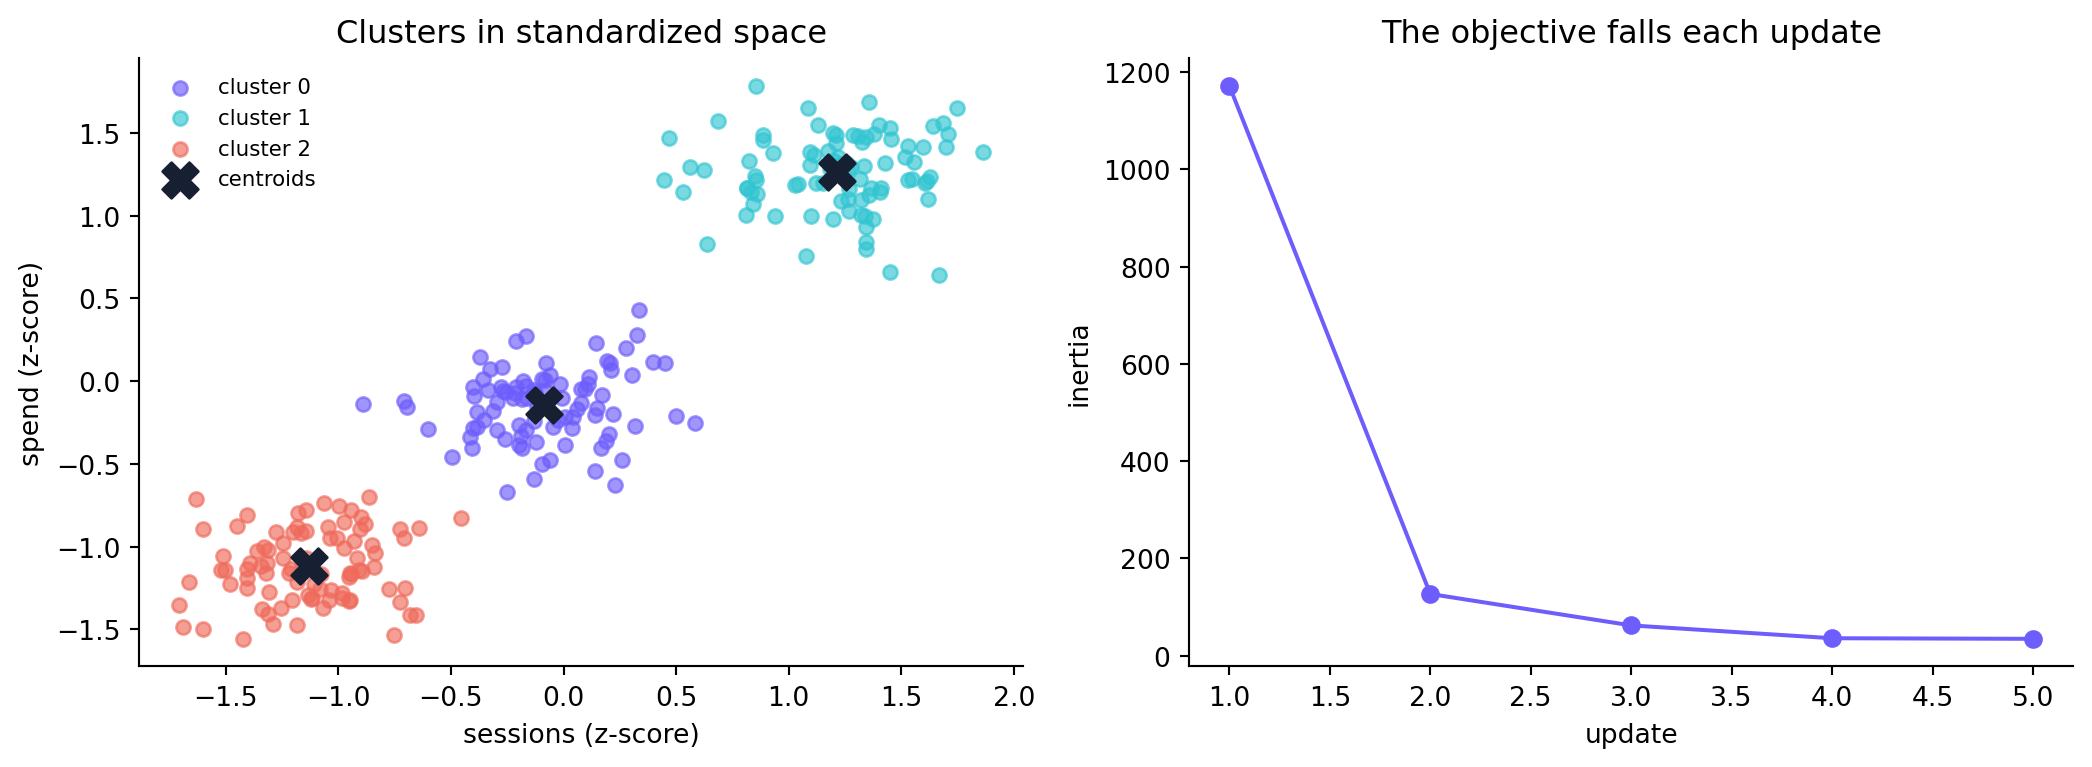

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.1))
palette = ["#6d5dfc", "#32c5d2", "#ef6a5b"]
for cluster, color in enumerate(palette):
    members = labels == cluster
    axes[0].scatter(X[members, 0], X[members, 1], s=28, alpha=.65, color=color, label=f"cluster {cluster}")
axes[0].scatter(centroids[:, 0], centroids[:, 1], marker="X", s=180, color="#172033", label="centroids")
axes[0].set(title="Clusters in standardized space", xlabel="sessions (z-score)", ylabel="spend (z-score)")
axes[0].legend(frameon=False, fontsize=8)

axes[1].plot(range(1, len(history) + 1), history, marker="o", color="#6d5dfc")
axes[1].set(title="The objective falls each update", xlabel="update", ylabel="inertia")
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

The cluster labels `0`, `1`, and `2` have no intrinsic order. Interpret the centroids in the original units before naming anything.

In [5]:
centroids_original = centroids * scale + mean
centroid_table = pd.DataFrame(centroids_original, columns=data.columns)
centroid_table["members"] = np.bincount(labels, minlength=3)
centroid_table.round(1)

,sessions_per_month,monthly_spend,members
0,42.0,133.9,90
1,72.8,262.2,90
2,17.4,45.3,90


## 3. Initialization creates local solutions

Run several seeds and keep the lowest-inertia result. This does not prove a global optimum, but it is far safer than trusting one random start.

In [6]:
runs = []
best = None
for seed in range(12):
    result = kmeans_once(X, k=3, seed=seed)
    runs.append({"seed": seed, "inertia": result[2], "updates": len(result[3])})
    if best is None or result[2] < best[2]:
        best = result
pd.DataFrame(runs).sort_values("inertia").round(2)

,seed,inertia,updates
0,0,34.64,4
1,1,34.64,4
2,2,34.64,5
3,3,34.64,6
4,4,34.64,5
5,5,34.64,3
6,6,34.64,5
7,7,34.64,10
8,8,34.64,4
9,9,34.64,10


## 4. Choosing $k$ is not purely mechanical

Inertia always falls as $k$ increases. An elbow plot asks where the improvement begins to flatten, but interpretability, stability, and the intended use of clusters matter too.

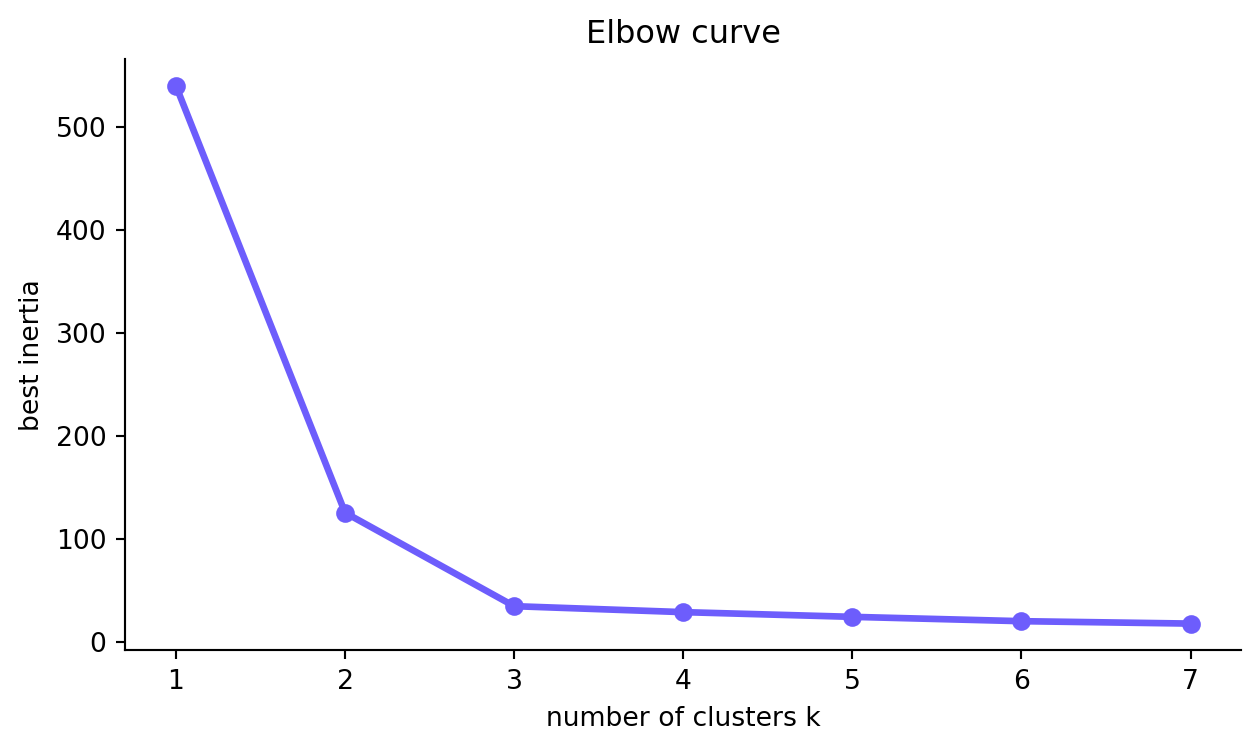

In [7]:
inertias = []
for k in range(1, 8):
    candidates = [kmeans_once(X, k=k, seed=seed)[2] for seed in range(8)]
    inertias.append(min(candidates))

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(range(1, 8), inertias, marker="o", linewidth=2.5, color="#6d5dfc")
ax.set(title="Elbow curve", xlabel="number of clusters k", ylabel="best inertia")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

## Where K-means struggles

K-means works best for compact, roughly spherical groups under Euclidean distance. It is sensitive to scaling and outliers, and it forces every point into a cluster. Curved shapes, very different densities, categorical variables, or clusters with unequal spread call for different representations or algorithms.

## Try it yourself

Run the algorithm on `X_raw` rather than standardized `X`. Compare the centroids and memberships. Then add ten extreme-spend observations and measure how the centroids move. Explain both changes in terms of squared distance. This completes the core **[Machine Learning course](index.html)**.